In [12]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

In [13]:
df = pd.read_csv("../data/cleaned_dataset.csv", index_col=0)

In [14]:
df.columns

Index(['site_name', 'delivery_time', 'production', 'installed_capacity',
       'utilization_rate', 'wind_speed_10m', 'wind_speed_100m',
       'wind_gusts_10m', 'temperature_2m', 'dewpoint_2m',
       'apparent_temperature', 'pressure_msl', 'surface_pressure',
       'precipitation', 'snowfall', 'cloud_cover', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_high', 'shortwave_radiation',
       'direct_radiation', 'diffuse_radiation', 'weather_code',
       'sunshine_duration', 'wind_speed_100m_cube', 'wind_shear',
       'wind_dir_100m_sin', 'wind_dir_100m_cos', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'is_maintenance', 'maint_rolling_sum',
       'is_confirmed_maint', 'is_curtailment', 'to_drop_for_training'],
      dtype='object')

In [30]:
def add_lag_rolling_features(df, target_col='utilization_rate'):
    """
    Ajoute LAG et ROLLING features sur les colonnes existantes,
    en s'assurant de ne pas utiliser de données à moins de 12h.
    """
    df = df.copy()
    df['delivery_time'] = pd.to_datetime(df['delivery_time'])
    
    # Création des lags de base
    for lag in [12, 24, 36]:
        df[f'{target_col}_lag_{lag}h'] = df.groupby('site_name')[target_col].shift(lag)
        df[f'wind_100m_lag_{lag}h'] = df.groupby('site_name')['wind_speed_100m'].shift(lag)
    
    # Moyennes et écart-types glissants appliqués sur la donnée décalée de 12h
    for window in [12, 24]:
        # On décale d'abord de 12h (`.shift(12)`), puis on calcule la rolling window
        df[f'{target_col}_rolling_mean_{window}h_lag12'] = df.groupby('site_name')[target_col].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )
        
        df[f'{target_col}_rolling_std_{window}h_lag12'] = df.groupby('site_name')[target_col].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).std()
        )
        
        df[f'wind_100m_rolling_mean_{window}h_lag12'] = df.groupby('site_name')['wind_speed_100m'].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )

        df[f'temp_rolling_mean_{window}h_lag12'] = df.groupby('site_name')['temperature_2m'].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )
        
        df[f'radiation_rolling_mean_{window}h_lag12'] = df.groupby('site_name')['shortwave_radiation'].transform(
            lambda x: x.shift(12).rolling(window=window, min_periods=1).mean()
        )
    
    # Évolution de la production (tendances) calculées uniquement avec des données >= 12h
    df[f'{target_col}_change_12h_24h'] = df[f'{target_col}_lag_12h'] - df[f'{target_col}_lag_24h']
    df[f'{target_col}_change_24h_36h'] = df[f'{target_col}_lag_24h'] - df[f'{target_col}_lag_36h']
    
    df['wind_change_12h_24h'] = df['wind_100m_lag_12h'] - df['wind_100m_lag_24h']
    
    df['day_of_week'] = df['delivery_time'].dt.dayofweek
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
    
    return df

df_featured = add_lag_rolling_features(df, target_col='utilization_rate')

print(f"Colonnes avant : {len(df.columns)}")
print(f"Colonnes après : {len(df_featured.columns)}")
print(f"\nNouvelles colonnes ajoutées : {len(df_featured.columns) - len(df.columns)}")
print(f"NaN introduits : {df_featured.isnull().sum().sum()}")

Colonnes avant : 37
Colonnes après : 58

Nouvelles colonnes ajoutées : 21
NaN introduits : 3520


In [31]:
df_featured['utilization_rate_24h'] = df_featured.groupby('site_name')['utilization_rate'].shift(-24)

On rajoute les données du forecast pendant la période de la prédiction:

In [32]:
df_featured.columns

Index(['site_name', 'delivery_time', 'production', 'installed_capacity',
       'utilization_rate', 'wind_speed_10m', 'wind_speed_100m',
       'wind_gusts_10m', 'temperature_2m', 'dewpoint_2m',
       'apparent_temperature', 'pressure_msl', 'surface_pressure',
       'precipitation', 'snowfall', 'cloud_cover', 'cloud_cover_low',
       'cloud_cover_mid', 'cloud_cover_high', 'shortwave_radiation',
       'direct_radiation', 'diffuse_radiation', 'weather_code',
       'sunshine_duration', 'wind_speed_100m_cube', 'wind_shear',
       'wind_dir_100m_sin', 'wind_dir_100m_cos', 'hour_sin', 'hour_cos',
       'month_sin', 'month_cos', 'is_maintenance', 'maint_rolling_sum',
       'is_confirmed_maint', 'is_curtailment', 'to_drop_for_training',
       'utilization_rate_lag_12h', 'wind_100m_lag_12h',
       'utilization_rate_lag_24h', 'wind_100m_lag_24h',
       'utilization_rate_lag_36h', 'wind_100m_lag_36h',
       'utilization_rate_rolling_mean_12h_lag12',
       'utilization_rate_rolling_st

In [33]:
# weather_cols = [
#     'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m',
#     'temperature_2m', 'dewpoint_2m', 'apparent_temperature',
#     'pressure_msl', 'surface_pressure', 'precipitation', 'snowfall',
#     'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
#     'shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
#     'sunshine_duration', 'wind_speed_100m_cube', 'wind_shear',
#     'wind_dir_100m_sin', 'wind_dir_100m_cos'
# ]

# for col in weather_cols:
#     if col in df_featured.columns and f'{col}_24h_ahead' not in df_featured.columns:
#         df_featured[f'{col}_24h_ahead'] = df_featured.groupby('site_name')[col].shift(-24)

In [34]:
df_model = df_featured.dropna().copy()
df_model = df_model.sort_values('delivery_time').reset_index(drop=True)

print(f"Lignes conservées : {len(df_model)}/{len(df_featured)}")

features_to_exclude = [
    'site_name', 'delivery_time', 'production', 'to_drop_for_training',
    'utilization_rate_24h', 'utilization_rate'
    # # On enlève la météo observée (sans _24h_ahead):
    # 'wind_speed_10m', 'wind_speed_100m', 'wind_gusts_10m',
    # 'temperature_2m', 'dewpoint_2m', 'apparent_temperature',
    # 'pressure_msl', 'surface_pressure', 'precipitation', 'snowfall',
    # 'cloud_cover', 'cloud_cover_low', 'cloud_cover_mid', 'cloud_cover_high',
    # 'shortwave_radiation', 'direct_radiation', 'diffuse_radiation',
    # 'sunshine_duration', 'wind_speed_100m_cube', 'wind_shear',
    # 'wind_dir_100m_sin', 'wind_dir_100m_cos',
]

X = df_model.drop(columns=features_to_exclude)
y = df_model['utilization_rate_24h']

print(f"\nFeatures sélectionnées : {X.shape[1]}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print(f"\nData types:\n{X.dtypes.value_counts()}")

Lignes conservées : 228969/229569

Features sélectionnées : 53
X shape: (228969, 53)
y shape: (228969,)

Data types:
float64    48
int64       4
int32       1
Name: count, dtype: int64


In [35]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, 
    test_size=0.4,
    shuffle=False
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    shuffle=False
)

print(f"\nTrain size: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val size:   {len(X_val)} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test size:  {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")


feature_cols = [col for col in df_model.columns if col not in features_to_exclude]

print(f"\nFeatures sélectionnées: {len(feature_cols)}")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}   | y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   | y_test:  {y_test.shape}")


Train size: 137381 (60.0%)
Val size:   45794 (20.0%)
Test size:  45794 (20.0%)

Features sélectionnées: 53
X_train: (137381, 53) | y_train: (137381,)
X_val:   (45794, 53)   | y_val:   (45794,)
X_test:  (45794, 53)   | y_test:  (45794,)


In [36]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [37]:
model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=1,
    early_stopping_rounds=20,
    eval_metric='rmse'
)

model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_val_scaled, y_val)], # Evaluation sur le set de validation
    verbose=10
)

[0]	validation_0-rmse:33.38265
[10]	validation_0-rmse:32.43095
[20]	validation_0-rmse:32.66278
[26]	validation_0-rmse:32.83647


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,20
,enable_categorical,False
,eval_metric,'rmse'


In [38]:
y_train_pred = model.predict(X_train_scaled)
y_val_pred = model.predict(X_val_scaled)
y_test_pred = model.predict(X_test_scaled)

In [39]:
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"\nTrain set:")
print(f"  RMSE: {train_rmse:.4f}")
print(f"  MAE:  {train_mae:.4f}")
print(f"  R²:   {train_r2:.4f}")


Train set:
  RMSE: 27.1163
  MAE:  23.9999
  R²:   0.3677


In [40]:
val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
val_mae = mean_absolute_error(y_val, y_val_pred)
val_r2 = r2_score(y_val, y_val_pred)

print(f"\nValidation set:")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  MAE:  {val_mae:.4f}")
print(f"  R²:   {val_r2:.4f}")



Validation set:
  RMSE: 32.3022
  MAE:  28.5478
  R²:   0.0709


In [41]:
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nTest set:")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  MAE:  {test_mae:.4f}")
print(f"  R²:   {test_r2:.4f}")


Test set:
  RMSE: 32.6424
  MAE:  28.7107
  R²:   0.1027


In [42]:
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(20).to_string())


                             feature  importance
27                         month_cos    0.076398
2                    wind_speed_100m    0.073387
3                     wind_gusts_10m    0.070714
47  radiation_rolling_mean_24h_lag12    0.047017
1                     wind_speed_10m    0.046695
23                 wind_dir_100m_cos    0.034776
14                  cloud_cover_high    0.034492
8                   surface_pressure    0.029717
22                 wind_dir_100m_sin    0.028762
46       temp_rolling_mean_24h_lag12    0.028218
26                         month_sin    0.025858
7                       pressure_msl    0.025786
6               apparent_temperature    0.024616
41       temp_rolling_mean_12h_lag12    0.024407
52                        is_weekend    0.023305
45  wind_100m_rolling_mean_24h_lag12    0.022976
5                        dewpoint_2m    0.022970
51                       day_of_week    0.022477
40  wind_100m_rolling_mean_12h_lag12    0.019502
11                  

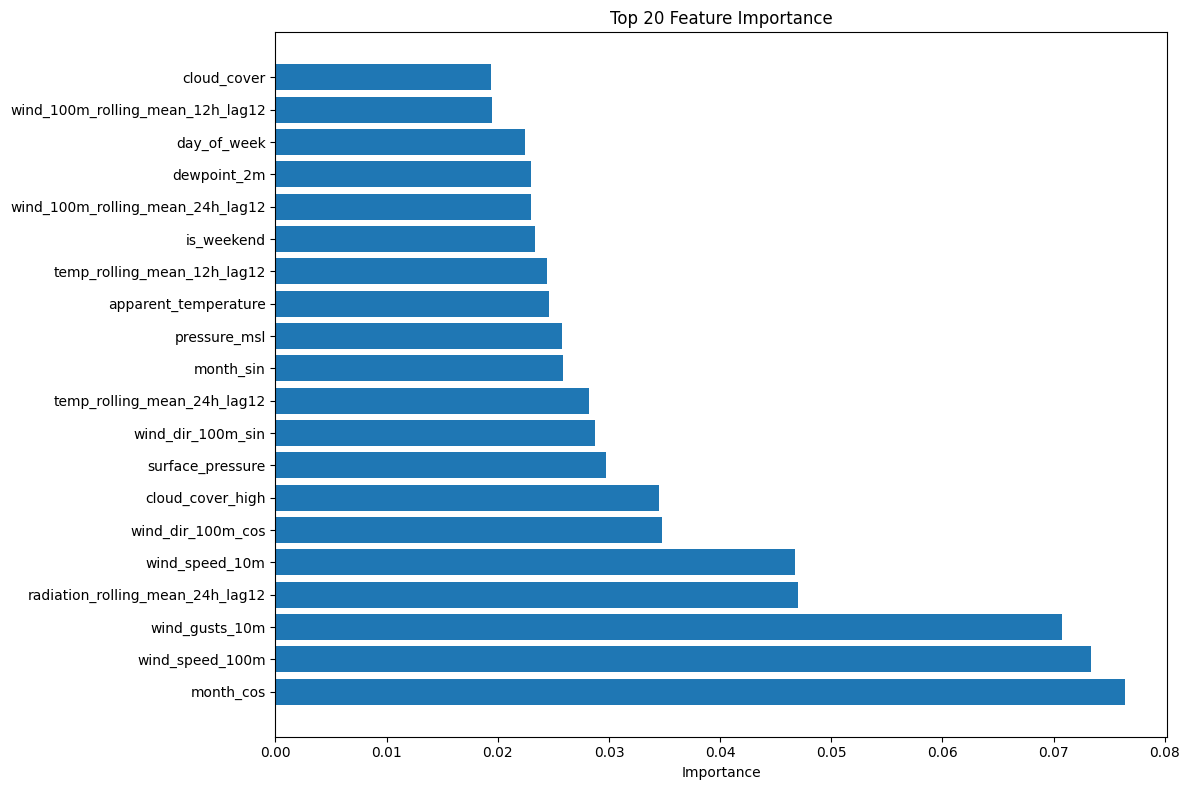

In [43]:
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)
plt.barh(range(len(top_features)), top_features['importance'])
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('Top 20 Feature Importance')
plt.tight_layout()
plt.show()